In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def padding(img, K_size):
    pad_size = K_size // 2
    padded_img = np.pad(img, ((pad_size, pad_size), (pad_size, pad_size)), mode='edge')
    return padded_img

### Erosion (侵蝕)

In [29]:
def manual_erosion(img, kernel):
    H, W = img.shape
    K_H, K_W = kernel.shape

    out = np.zeros((H, W), dtype=img.dtype)
    padded_img = padding(img, K_H)

    for i in range(H):
        for j in range(W):
            roi = padded_img[i : i + K_H, j : j + K_W]
            # 侵蝕 = 區域內的最小值 (Min)
            # 在二值影像中，只要有一個是0，最小值就是0
            valid_pixels = roi[kernel == 1]
            if len(valid_pixels) > 0:
                out[i, j] = np.min(valid_pixels)
            else:
                out[i, j] = 0

    return out

### Dilation (膨脹)

In [30]:
def manual_dilation(img, kernel):
    H, W = img.shape
    K_H, K_W = kernel.shape

    out = np.zeros((H, W), dtype=img.dtype)
    padded_img = padding(img, K_H)

    for i in range(H):
        for j in range(W):

            roi = padded_img[i : i + K_H, j : j + K_W]
            # 膨脹 = 區域內的最大值 (Max)
            # 在二值影像中，只要有一個是1，最大值就是1
            valid_pixels = roi[kernel == 1]
            if len(valid_pixels) > 0:
                out[i, j] = np.max(valid_pixels)
            else:
                out[i, j] = 0

    return out

### 斷開

In [31]:
def manual_opening(img, kernel):
    eroded = manual_erosion(img, kernel)
    opened = manual_dilation(eroded, kernel)
    return opened

### 閉合

In [32]:
def manual_closing(img, kernel):
    dilated = manual_dilation(img, kernel)
    closed = manual_erosion(dilated, kernel)
    return closed

### 形態學重建

Marker 已儲存為 marker_for_student.png


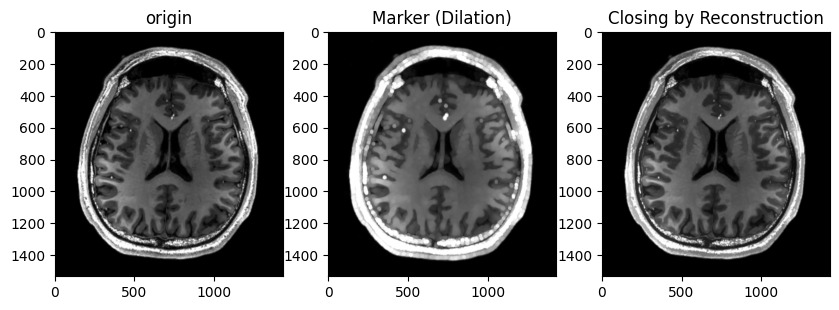

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import dilation, disk
from skimage.morphology import reconstruction
from skimage import io
from skimage import img_as_ubyte
# 讀圖
img = io.imread("/content/MRI_of_Human_Brain.jpg", as_gray=True)

# Step 1：dilation（膨脹產生 marker）
selem = disk(9)   # 半徑 3 可調
marker = dilation(img, selem)
marker_saved = img_as_ubyte(marker)

# 2. 存檔 (存成 png 以保留不失真的數值)
io.imsave('marker_for_student.png', marker_saved)

print("Marker 已儲存為 marker_for_student.png")
# Step 2：closing by reconstruction
closed = reconstruction(marker, img, method='erosion')


# 1. 將 marker 轉為 0-255 的標準影像格式 (uint8)
# 如果原始讀取是 float (0.0-1.0)，這步很重要，不然存檔可能會變全黑

# 顯示結果
plt.figure(figsize=(10,5))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title("origin")
plt.subplot(1,3,2); plt.imshow(marker, cmap='gray'); plt.title("Marker (Dilation)")
plt.subplot(1,3,3); plt.imshow(closed, cmap='gray'); plt.title("Closing by Reconstruction")
plt.show()


開始手動重建 (這可能需要一點時間)...
正在進行第 10 次迭代...
正在進行第 20 次迭代...
正在進行第 30 次迭代...
正在進行第 40 次迭代...
正在進行第 50 次迭代...
正在進行第 60 次迭代...
正在進行第 70 次迭代...
正在進行第 80 次迭代...
正在進行第 90 次迭代...
正在進行第 100 次迭代...
正在進行第 110 次迭代...
正在進行第 120 次迭代...
正在進行第 130 次迭代...
正在進行第 140 次迭代...
正在進行第 150 次迭代...
正在進行第 160 次迭代...
正在進行第 170 次迭代...
正在進行第 180 次迭代...
正在進行第 190 次迭代...
正在進行第 200 次迭代...
正在進行第 210 次迭代...
正在進行第 220 次迭代...
正在進行第 230 次迭代...
正在進行第 240 次迭代...
正在進行第 250 次迭代...
正在進行第 260 次迭代...
正在進行第 270 次迭代...
正在進行第 280 次迭代...
正在進行第 290 次迭代...
演算法在第 299 次迭代後收斂停止。


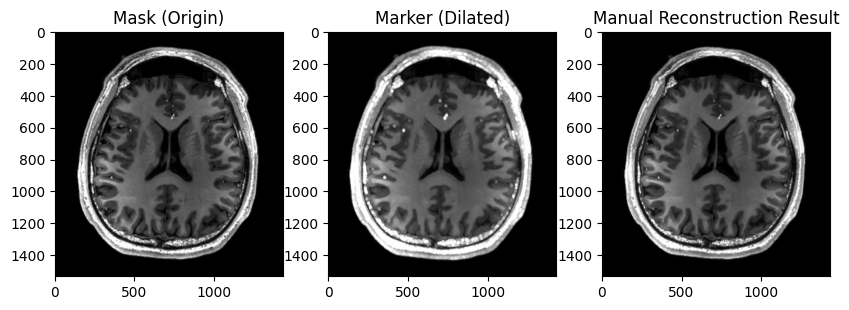

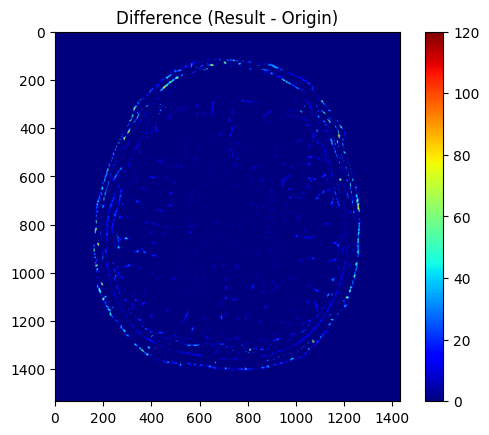

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import disk, erosion
from skimage import io, img_as_ubyte

# ==========================================
# 1. 準備資料 (模擬學生拿到的檔案)
# ==========================================
# 假設學生讀取了你給的圖
mask = io.imread("/content/MRI_of_Human_Brain.jpg", as_gray=True) # 原圖
marker = io.imread("/content/marker_for_student.png", as_gray=True)       # 膨脹圖

# 轉成 0-1 的浮點數比較好計算 (或是都保持 0-255 uint8 也可以)
mask = img_as_ubyte(mask)
marker = img_as_ubyte(marker)


def manual_reconstruction_erosion(marker, mask):
    current_marker = marker.copy()

    # 定義最基本的結構元素，上、下、左、右四連通
    selem = disk(1)

    iteration = 0
    while True:
        iteration += 1
        #1.腐蝕，讓marker高度開始降下
        eroded = erosion(current_marker, selem)

        #2.控制高度，不可小於mask
        reconstructed = np.maximum(eroded, mask)

        #3.檢查收斂，當值不在改變跳脫迴圈
        if np.array_equal(current_marker, reconstructed):
            print(f"演算法在第 {iteration} 次迭代後收斂停止。")
            break

        # 更新目前的影像，準備下一輪
        current_marker = reconstructed

        if iteration % 10 == 0:
            print(f"正在進行第 {iteration} 次迭代...")

    return current_marker


print("開始手動重建 (這可能需要一點時間)...")
result_manual = manual_reconstruction_erosion(marker, mask)

# 顯示結果
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1); plt.imshow(mask, cmap='gray'); plt.title("Mask (Origin)")
plt.subplot(1, 3, 2); plt.imshow(marker, cmap='gray'); plt.title("Marker (Dilated)")
plt.subplot(1, 3, 3); plt.imshow(result_manual, cmap='gray'); plt.title("Manual Reconstruction Result")
plt.show()

# 驗證差異 (全黑代表完美)
diff = result_manual - mask
plt.imshow(diff, cmap='jet')
plt.title("Difference (Result - Origin)")
plt.colorbar()
plt.show()

### test

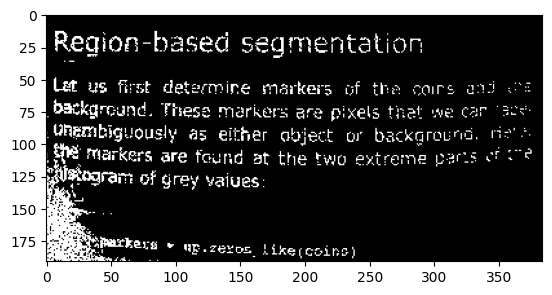

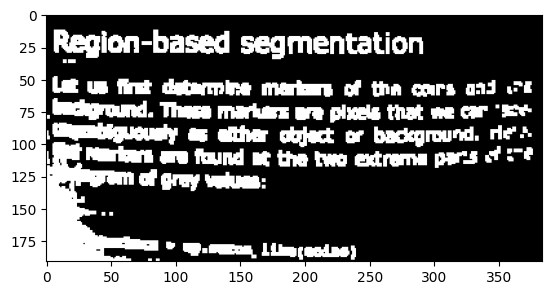

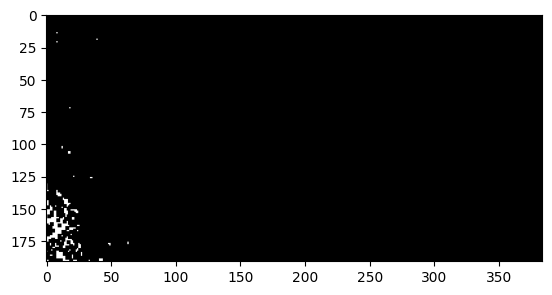

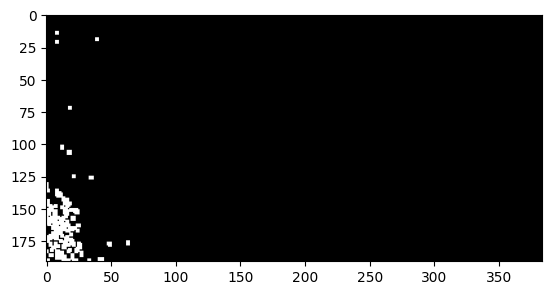

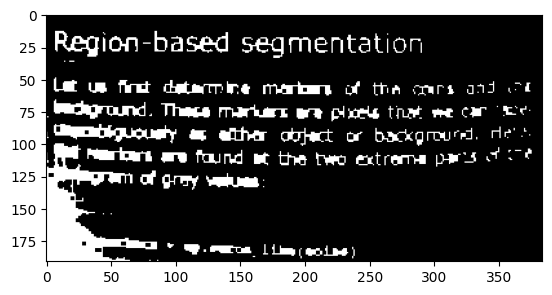

In [62]:

# 1. 建立一個簡單的測試矩陣 (模擬二值影像)
# 10x10 的影像，中間有一個十字形，右下有一個噪點
input_img = cv2.imread("/content/text_noisy.png",cv2.IMREAD_GRAYSCALE)

# 2. 定義結構元素 (Kernel) - 3x3 矩形
structuring_element = np.ones((3, 3), dtype=np.uint8)

# 3. 執行運算
res_dilate = manual_dilation(input_img, structuring_element)
res_erode = manual_erosion(input_img, structuring_element)
res_open = manual_opening(input_img, structuring_element)
res_close = manual_closing(input_img, structuring_element)

# 4. 顯示結果 (使用 print 顯示矩陣數值，方便觀察變化)
plt.imshow(input_img, cmap='gray')
plt.show()
plt.imshow(res_dilate, cmap='gray')
plt.show()
plt.imshow(res_erode, cmap='gray')
plt.show()
plt.imshow(res_open, cmap='gray')
plt.show()
plt.imshow(res_close, cmap='gray')
plt.show()

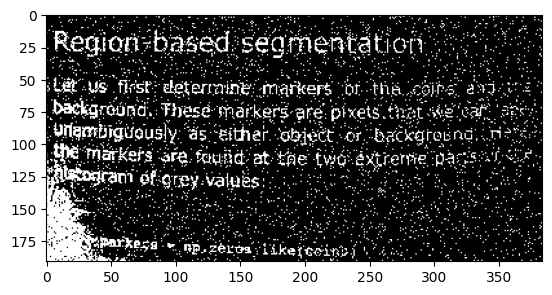

In [41]:
input_img = cv2.imread("/content/binary.png",cv2.IMREAD_GRAYSCALE)
noisy_image = input_img.copy()
salt_prob = 0.05
pepper_prob = 0.05

# 生成隨機矩陣
random_matrix = np.random.random(input_img.shape[:2])

# 添加鹽雜訊(白點 = 255)
noisy_image[random_matrix < salt_prob] = 255

# 添加椒雜訊(黑點 = 0)
noisy_image[random_matrix > 1 - pepper_prob] = 0
plt.imshow(noisy_image, cmap='gray')

In [46]:
import cv2
import numpy as np

# 讀圖（灰階）
img = cv2.imread("/content/binary.png", cv2.IMREAD_GRAYSCALE)

# --- Step 1: 找出白色文字區域（根據亮度） ---
# 閾值依圖片可調整，190–220 常用來抓白字
_, text_mask = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)

# 轉成 0/1 mask
mask = (text_mask == 255)

# --- Step 2: 建立 salt & pepper noise ---
noise = np.copy(img)

# 比例（可調）：每個像素 3% 變白/黑
prob = 0.25

salt = np.random.rand(*img.shape) < (prob / 2)
pepper = np.random.rand(*img.shape) < (prob / 2)

# 只在「白字區域」加入雜訊
noise[salt & mask] = 255      # salt
noise[pepper & mask] = 0      # pepper

# --- Step 3: 輸出 ---
cv2.imwrite("text_noisy.png", noise)


True